1. Import all the libraries

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

2. Load the Datasheet

In [ ]:

df = pd.read_csv("sales_satisfaction.csv")

3. Check datasheet balanced or not using pie chart


📊 STEP 2: BALANCE CHECK (PIE CHARTS)


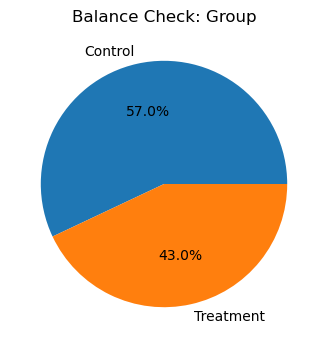

✓ Group is balanced


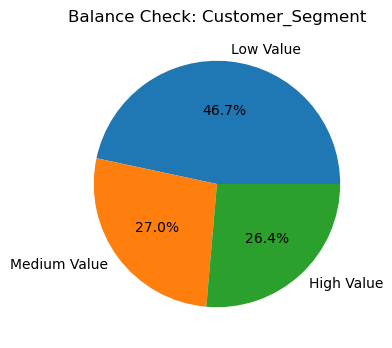

✓ Customer_Segment is balanced


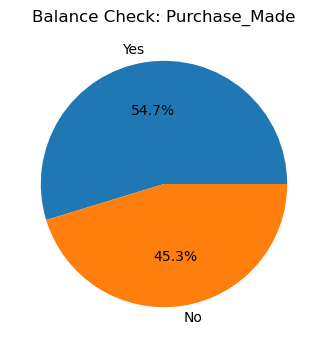

✓ Purchase_Made is balanced


In [ ]:

print("\n📊 STEP 2: BALANCE CHECK (PIE CHARTS)")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot.pie(autopct='%1.1f%%')
    plt.title(f"Balance Check: {col}")
    plt.ylabel("")
    plt.show()
    
    max_percent = df[col].value_counts(normalize=True).max() * 100
    if max_percent > 70:
        print(f"⚠️ {col} is IMBALANCED (Dominant category: {max_percent:.1f}%)")
    else:
        print(f"✓ {col} is balanced")

4. Find the column type.

In [ ]:
import pandas as pd

df = pd.read_csv("sales_satisfaction.csv")

def classify_column(column):
    if pd.api.types.is_numeric_dtype(column):
        if column.nunique() < 20 and column.dtype == 'int64':
            return "Numeric (Discrete)"
        else:
            return "Numeric (Continuous)"
    else:
        if column.nunique() < 10:
            return "Categorical (Ordinal/Nominal)"
        else:
            return "Categorical (Nominal)"

type_report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': [classify_column(df[col]) for col in df.columns],
    'Unique Values': df.nunique()
})
port
print("COLUMN DATA TYPE ANALYSIS:")
print(type_report.to_string(index=False))

COLUMN DATA TYPE ANALYSIS:
                      Column                     Data Type  Unique Values
                       Group Categorical (Ordinal/Nominal)              2
            Customer_Segment Categorical (Ordinal/Nominal)              3
                Sales_Before          Numeric (Continuous)           8388
                 Sales_After          Numeric (Continuous)           9143
Customer_Satisfaction_Before          Numeric (Continuous)           7731
 Customer_Satisfaction_After          Numeric (Continuous)           7033
               Purchase_Made Categorical (Ordinal/Nominal)              2


5. Using pandas count the target on bar chart

Using column 'Purchase_Made' as target


<Axes: xlabel='Purchase_Made'>

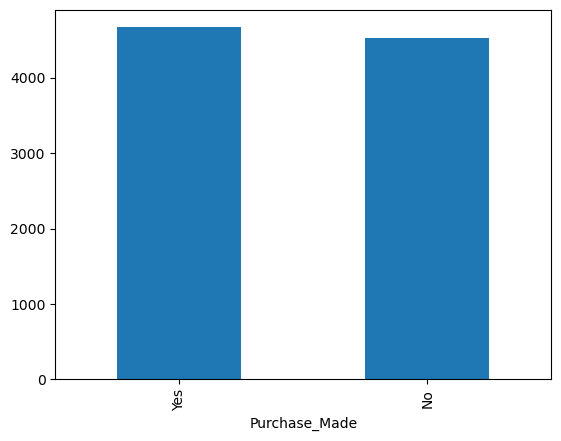

In [ ]:

df = pd.read_csv("sales_satisfaction.csv")

target_col = df.columns[-1]  
for name in ['target', 'label', 'class', 'rating', 'score']:
    if name in df.columns:
        target_col = name
        break

print(f"Using column '{target_col}' as target")
target_counts = df[target_col].value_counts()
target_counts.plot.bar()  

6. Calculate mean median variance if it is continous, and if it is categorical calculate percentage and frequency.

In [ ]:

def analyze_column(column_data):
    if pd.api.types.is_numeric_dtype(column_data):
        if column_data.nunique() > 10:  
            return {
                'Type': 'Continuous Numerical',
                'Mean': column_data.mean(),
                'Median': column_data.median(),
                'Mode': column_data.mode()[0],
                'Variance': column_data.var(),
                'Std Dev': column_data.std()
            }
        else:  
            counts = column_data.value_counts()
            return {
                'Type': 'Discrete Numerical',
                'Value Counts': counts,
                'Percentage': (counts / len(column_data)) * 100  
            }
    else:  
        counts = column_data.value_counts()
        return {
            'Type': 'Categorical',
            'Value Counts': counts,
            'Percentage': (counts / len(column_data)) * 100  
        }

for col in df.columns:
    print(f"\n🔍 Column: {col}")
    stats = analyze_column(df[col])
    
    if stats['Type'] == 'Continuous Numerical':
        print(f"Type: {stats['Type']}")
        print(f"Mean: {stats['Mean']:.2f}")
        print(f"Median: {stats['Median']:.2f}") 
        print(f"Mode: {stats['Mode']:.2f}")
        print(f"Variance: {stats['Variance']:.2f}")
        print(f"Standard Deviation: {stats['Std Dev']:.2f}")
    else:
        print(f"Type: {stats['Type']}")
        print("Value Distribution:")
        display(pd.DataFrame({
            'Count': stats['Value Counts'],
            'Percentage': stats['Percentage'].round(1)
        }))  


🔍 Column: Group
Type: Categorical
Value Distribution:


,Count,Percentage
Group,,
Control,5701,57.0
Treatment,4299,43.0



🔍 Column: Customer_Segment
Type: Categorical
Value Distribution:


,Count,Percentage
Customer_Segment,,
Low Value,4665,46.7
Medium Value,2697,27.0
High Value,2638,26.4



🔍 Column: Sales_Before
Type: Continuous Numerical
Mean: 203.72
Median: 203.72
Mode: 203.72
Variance: 2590.08
Standard Deviation: 50.89

🔍 Column: Sales_After
Type: Continuous Numerical
Mean: 280.46
Median: 280.46
Mode: 280.46
Variance: 6774.71
Standard Deviation: 82.31

🔍 Column: Customer_Satisfaction_Before
Type: Continuous Numerical
Mean: 70.25
Median: 70.25
Mode: 70.25
Variance: 239.52
Standard Deviation: 15.48

🔍 Column: Customer_Satisfaction_After
Type: Continuous Numerical
Mean: 73.87
Median: 73.87
Mode: 73.87
Variance: 274.74
Standard Deviation: 16.58

🔍 Column: Purchase_Made
Type: Categorical
Value Distribution:


,Count,Percentage
Purchase_Made,,
Yes,5472,54.7
No,4528,45.3


7. Plot statistics.

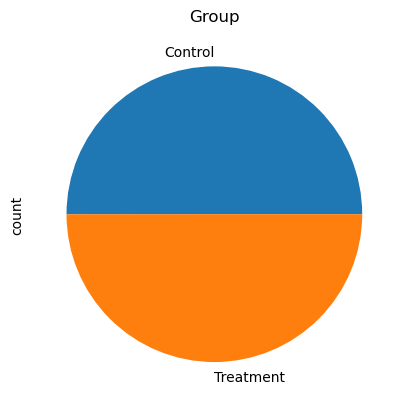

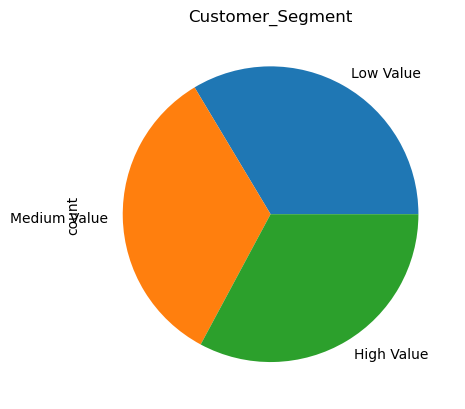

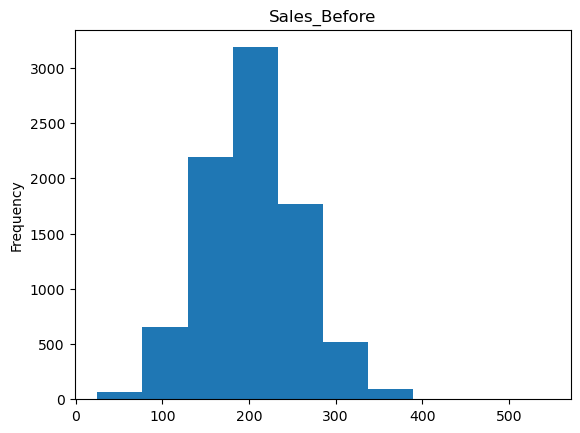

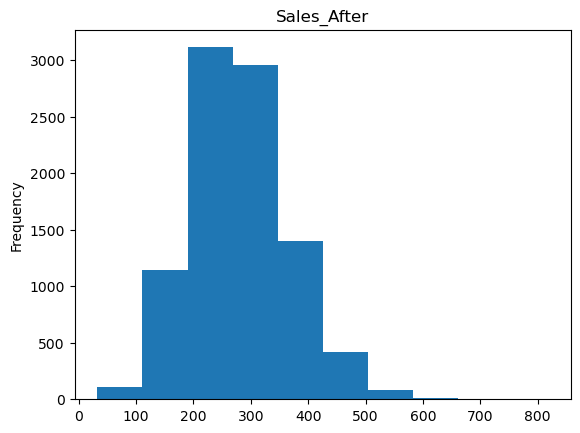

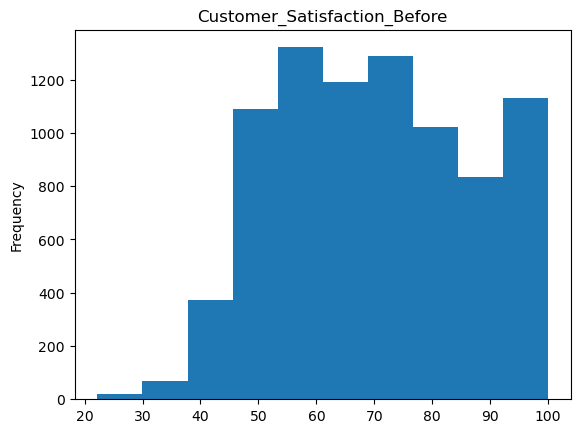

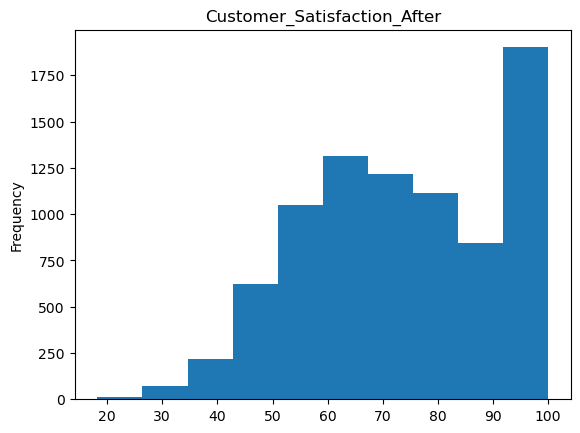

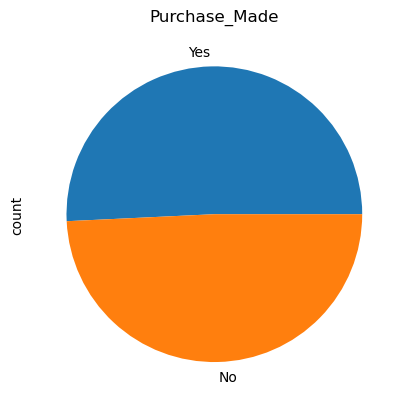

In [ ]:
for col in df:
    if pd.api.types.is_numeric_dtype(df[col]):
        if df[col].nunique() > 10:
            df[col].plot.hist(title=col)  
        else:
            df[col].value_counts().plot.bar(title=col)  
    else:
        if df[col].nunique() <= 5:
            df[col].value_counts().plot.pie(title=col)  
        else:
            df[col].value_counts().head(10).plot.bar(title=col)  
    plt.show()

8. Correlation with each column to each column and its result.

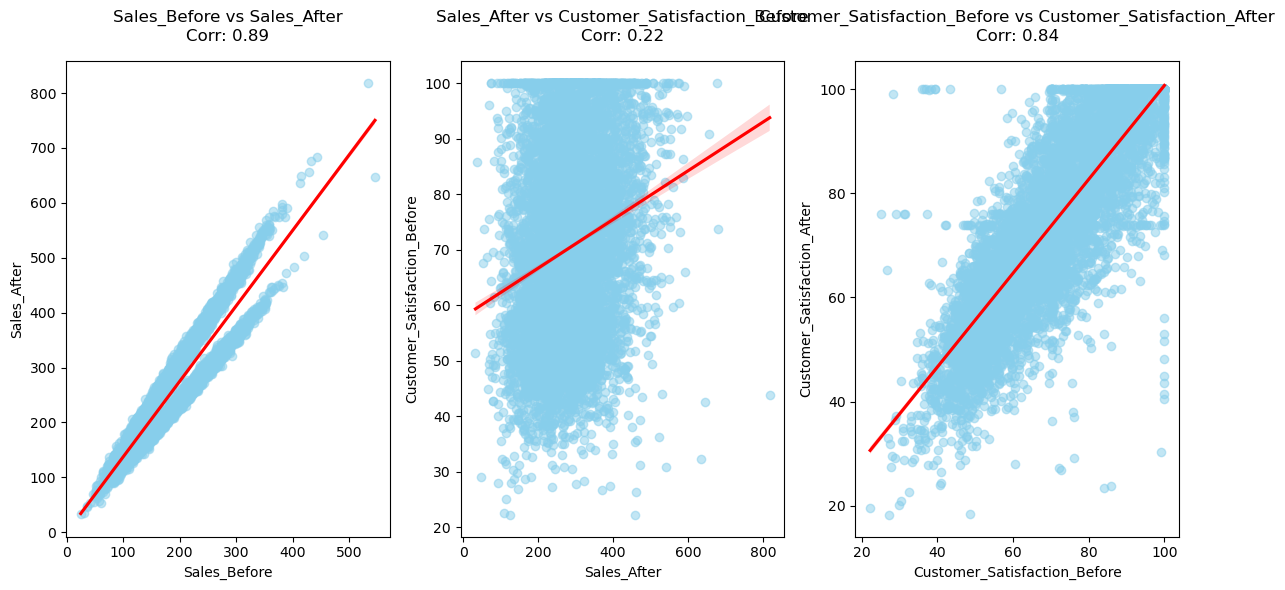

SEQUENTIAL CORRELATION REPORT:
Sales_Before    → Sales_After    : 0.89 (Strong ↑ Positive)
Sales_After     → Customer_Satisfaction_Before: 0.22 (Weak ↑ Positive)
Customer_Satisfaction_Before → Customer_Satisfaction_After: 0.84 (Strong ↑ Positive)


In [ ]:

numeric_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(12, 6))
plot_count = len(numeric_cols) - 1

for i in range(plot_count):
    col1 = numeric_cols[i]
    col2 = numeric_cols[i+1]
    corr = df[col1].corr(df[col2])
    

    plt.subplot(1, plot_count, i+1)
    sns.regplot(x=col1, y=col2, data=df, 
                scatter_kws={'alpha':0.5, 'color':'skyblue'},
                line_kws={'color':'red'})
    
    
    plt.title(f"{col1} vs {col2}\nCorr: {corr:.2f}", pad=15)
    plt.xlabel(col1)
    plt.ylabel(col2)

plt.tight_layout()
plt.show()

print("SEQUENTIAL CORRELATION REPORT:")
for i in range(len(numeric_cols)-1):
    col1 = numeric_cols[i]
    col2 = numeric_cols[i+1]
    corr = df[col1].corr(df[col2])
    
    strength = "Strong" if abs(corr) > 0.7 else \
               "Moderate" if abs(corr) > 0.3 else "Weak"
    
    direction = "↑ Positive" if corr > 0 else "↓ Negative"
    
    print(f"{col1:15} → {col2:15}: {corr:.2f} ({strength} {direction})")

9. Correlation heat map

Pairwise Column Correlations:
                              Sales_Before  Sales_After  Customer_Satisfaction_Before  Customer_Satisfaction_After
Sales_Before                          1.00         0.89                          0.26                         0.24
Sales_After                           0.89         1.00                          0.22                         0.20
Customer_Satisfaction_Before          0.26         0.22                          1.00                         0.84
Customer_Satisfaction_After           0.24         0.20                          0.84                         1.00


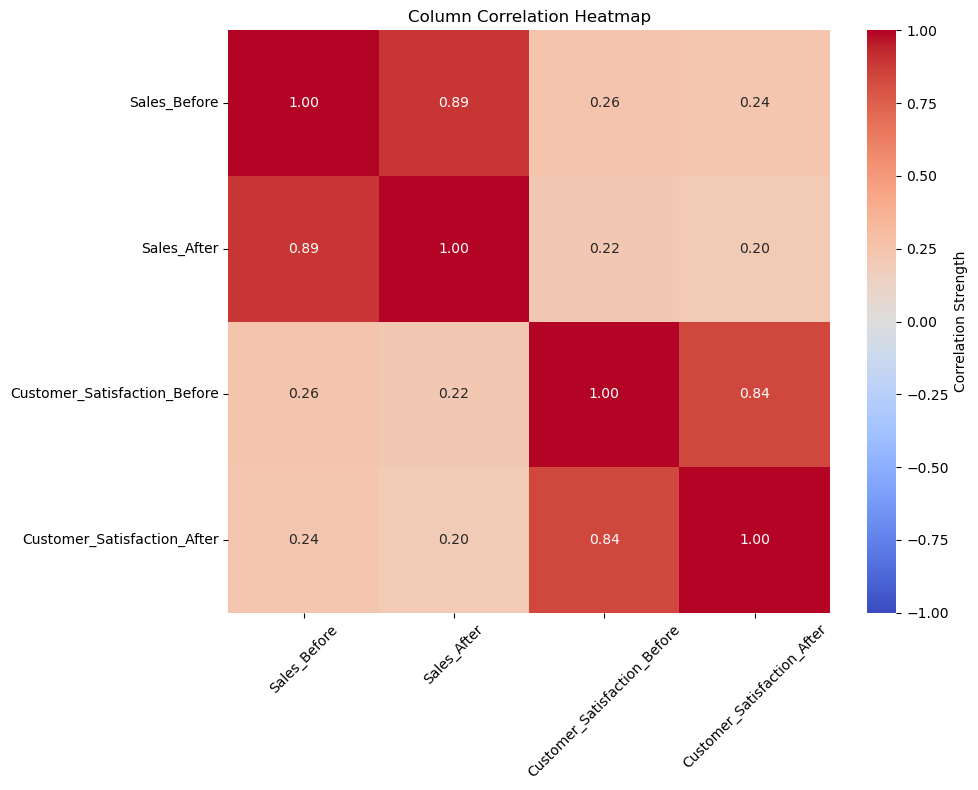

In [ ]:

corr_matrix = df.corr(numeric_only=True)  


print("Pairwise Column Correlations:")
print(corr_matrix.round(2).to_string())  

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            center=0,
            cbar_kws={'label': 'Correlation Strength'})
plt.title("Column Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

10. Convert categorical data to numerical data

In [ ]:

from sklearn.preprocessing import LabelEncoder


your_file = "sales_satisfaction.csv"  

try:
    df = pd.read_csv(your_file)
    
 
    for col in df.select_dtypes(include=['object', 'category']).columns:
        if df[col].nunique() < 10:
            df[col] = LabelEncoder().fit_transform(df[col])
        else:
            freq = df[col].value_counts(normalize=True)
            df[col] = df[col].map(freq)
    
    print("Success! Categorical columns converted to numeric.")
    print("Modified columns:", list(df.select_dtypes(include=['object', 'category']).columns))

except FileNotFoundError:
    print(f"ERROR: File '{your_file}' not found. Please:")
    print("1. Check the filename is correct")
    print("2. Make sure the file is in your current folder")
    print("3. Try the full file path if needed (e.g., 'C:/folder/your_file.csv')")

Success! Categorical columns converted to numeric.
Modified columns: []


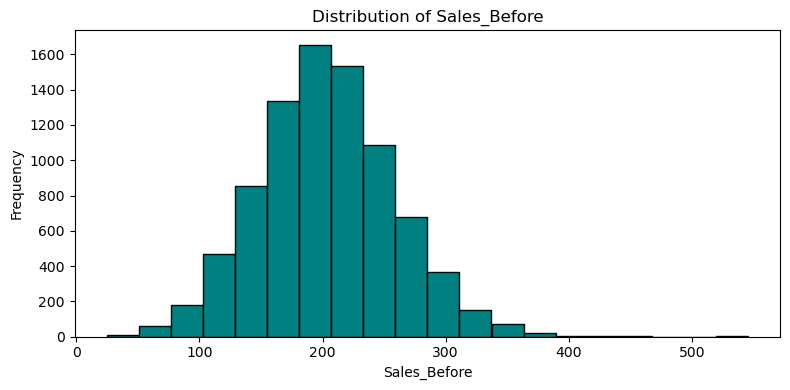

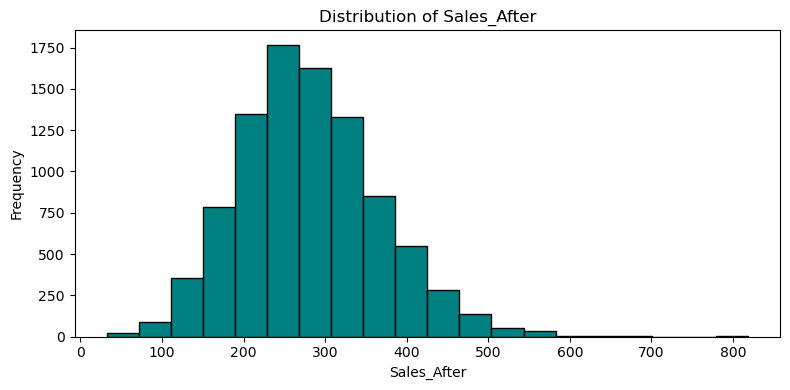

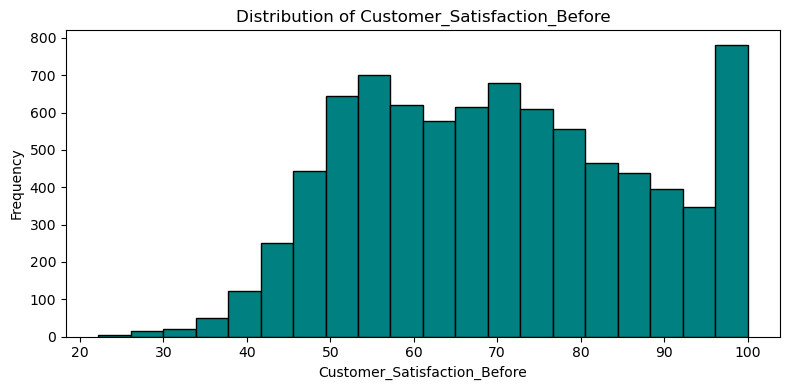

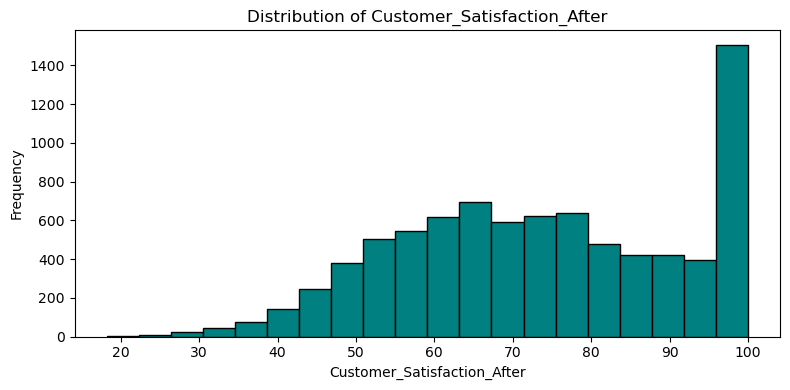

In [ ]:

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    df[col].plot.hist(bins=20, color='teal', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(f'{col}_histogram.png')  
    plt.show()

11. Check if there is any missing values.

In [ ]:

missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values[missing_values > 0])

print("\nTotal missing values in dataset:", df.isnull().sum().sum())

Missing values per column:
Group                           1401
Customer_Segment                1966
Sales_Before                    1522
Sales_After                      767
Customer_Satisfaction_Before    1670
Customer_Satisfaction_After     1640
Purchase_Made                    805
dtype: int64

Total missing values in dataset: 9771


12. Handling the missing values with mean and mode.

In [ ]:

df = df.dropna(how='all')  


print("\n=== Mean (Numeric Columns) ===")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    mean_val = df[col].mean()
    print(f"{col}: Mean = {mean_val:.2f}") 

print("\n=== Mode (Categorical Columns) ===")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_val = df[col].mode()[0]  
    
    print(f"{col}: Mode = '{mode_val}'")

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())


for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


print("\n=== Missing Values After Imputation ===")
print(df.isnull().sum())

print("\nFinal DataFrame shape:", df.shape)


=== Mean (Numeric Columns) ===
Sales_Before: Mean = 203.72
Sales_After: Mean = 280.46
Customer_Satisfaction_Before: Mean = 70.25
Customer_Satisfaction_After: Mean = 73.87

=== Mode (Categorical Columns) ===
Group: Mode = 'Control'
Customer_Segment: Mode = 'Low Value'
Purchase_Made: Mode = 'Yes'

=== Missing Values After Imputation ===
Group                           0
Customer_Segment                0
Sales_Before                    0
Sales_After                     0
Customer_Satisfaction_Before    0
Customer_Satisfaction_After     0
Purchase_Made                   0
dtype: int64

Final DataFrame shape: (10000, 7)
